In [ ]:
#Random Forest Calibration and Locations

In [20]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from geopy.geocoders import Nominatim
import time

# Load the dataset
file_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Rh_Ak/Data/Accidentes_Carabineros_2021.csv'
data = pd.read_csv(file_path)

# Filter and clean the dataset
data = data[data["Comuna"] == "PROVIDENCIA"][["Muertos", "Graves", "M/Grave", "Leves", "Ilesos", "Calleuno", "Calledos"]]

def clean_column(data):
    if isinstance(data, str):
        return data.split(' =>')[0]
    else:
        return data  # or you can return an empty string '' if that's preferable

data['Calleuno'] = data['Calleuno'].apply(clean_column)
data['Calledos'] = data['Calledos'].apply(clean_column)

# Combine street names into one identifier column for uniqueness
data['Location'] = data['Calleuno'] + ' and ' + data['Calledos']

# Create a severity score
weights = {'Muertos': 5, 'Graves': 4, 'M/Grave': 3, 'Leves': 2, 'Ilesos': 1}
data['Severity'] = (data['Muertos'] * weights['Muertos'] +
                    data['Graves'] * weights['Graves'] +
                    data['M/Grave'] * weights['M/Grave'] +
                    data['Leves'] * weights['Leves'] +
                    data['Ilesos'] * weights['Ilesos'])

# Features and target
features = data[['Muertos', 'Graves', 'M/Grave', 'Leves', 'Ilesos']]
target = data['Severity']

# Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(features, target)
data['Predicted_Severity'] = rf.predict(features)

# Drop duplicate locations based on the new 'Location' column
unique_data = data.drop_duplicates(subset='Location')

# Select the top 58 unique locations
top_locations = unique_data.sort_values(by='Predicted_Severity', ascending=False).head(61)
print(top_locations.head(61))


       Muertos  Graves  M/Grave  Leves  Ilesos                Calleuno  \
23533        1       0        1      0       3            ANDRES BELLO   
34975        0       2        0      0       1        FRANCISCO BILBAO   
58977        0       1        0      2       0          PADRE LETELIER   
42863        0       2        0      0       0                RANCAGUA   
50140        0       2        0      0       0  CARLOS WALKER MARTINEZ   
...        ...     ...      ...    ...     ...                     ...   
1423         0       1        0      0       1              COST NORTE   
43718        0       1        0      0       1           ANTONIO VARAS   
40461        0       1        0      0       1         VICUNA MACKENNA   
42657        0       1        0      0       1          RENATO ZANELLI   
76376        0       0        0      2       1     JOSE MANUEL INFANTE   

                      Calledos                               Location  \
23533              NVA DE LYON        

In [16]:
#output_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Rh_Ak/Random_Forest_Camera_Positions.csv'
#top_locations.to_csv(output_path, index=False)

#print(f"Data saved to {output_path}")

Data saved to /Users/sebi/Documents/Datos Tesis MIIIO/Random_Forest_Camera_Positions.csv


In [ ]:
#Solution Plots: Linear

<Figure size 1200x800 with 0 Axes>

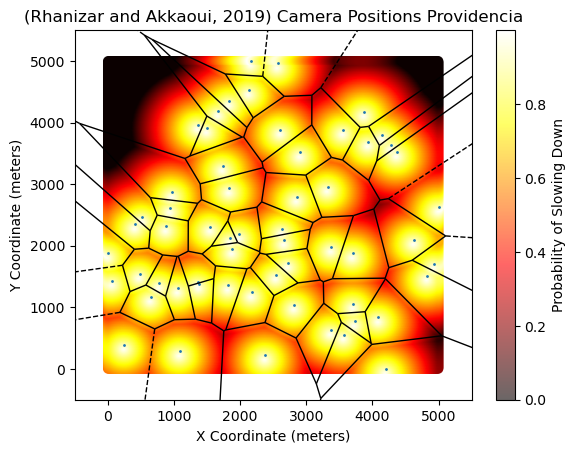

Average Coverage Probability: 0.5667481649461447


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.stats import ttest_rel

# Record the start time
start_time = time.time()


# Load the crash data
provi_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Rh_Ak/Data/Random_Forest_Camera_Positions_Coordinates.csv')  # Replace with your file path
provi_df[['Y', 'X']] = provi_df['(X,Y)'].str.split(',', expand=True).astype(float)  # Split the column into two new columns and convert to float
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
min_distance = 500


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
probability_threshold = 0.7  # Probability threshold for coverage


# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    # Linear function parameters as solved previously
    a = -1/1000
    b = 1
    probability = a * dist + b
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)
    
# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, '(Rhanizar and Akkaoui, 2019) Camera Positions Providencia Linear Function')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)

# Save to CSV
#comparison_output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Rh_Ak/Data/Rhanizar_Akkaoui_Camera_Positions_Coordinates_Final.csv'  # Adjust the path as necessary
#provi_df.to_csv(comparison_output_csv_path, index=False)

In [ ]:
#Solution Plots: Logarithmic

<Figure size 1200x800 with 0 Axes>

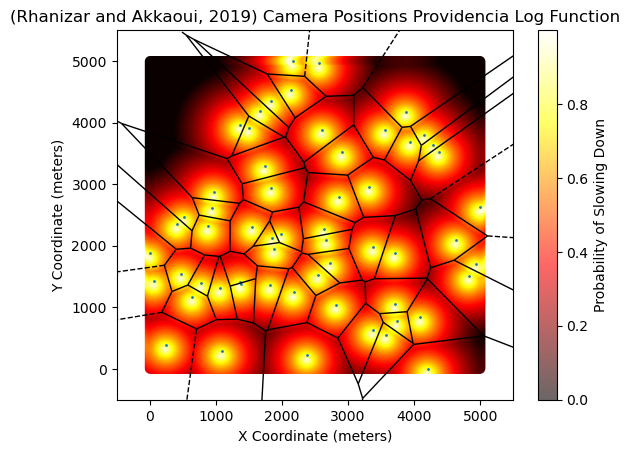

Average Coverage Probability: 0.4085880633466398


In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.stats import ttest_rel

# Record the start time
start_time = time.time()


# Load the crash data
provi_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Rh_Ak/Data/Providencia/Random_Forest_Camera_Positions_Coordinates.csv')  # Replace with your file path
provi_df[['Y', 'X']] = provi_df['(X,Y)'].str.split(',', expand=True).astype(float)  # Split the column into two new columns and convert to float
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
min_distance = 500


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
probability_threshold = 0.7  # Probability threshold for coverage


# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    k = 0.005
    probability = 1 - np.log(1 + k * dist) / np.log(1 + k * 1000)
    # Ensure the probability is never negative and does not exceed 1, applied to each element of the array
    probability = np.clip(probability, 0, 1)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)
    
# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, '(Rhanizar and Akkaoui, 2019) Camera Positions Providencia Log Function')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


In [ ]:
#Solution Plots: Quadratic

<Figure size 1200x800 with 0 Axes>

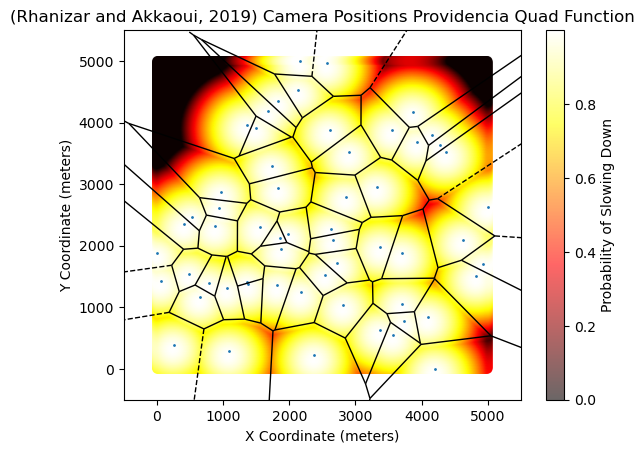

Average Coverage Probability: 0.7313390130169102


In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.stats import ttest_rel

# Record the start time
start_time = time.time()


# Load the crash data
provi_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Rh_Ak/Data/Providencia/Random_Forest_Camera_Positions_Coordinates.csv')  # Replace with your file path
provi_df[['Y', 'X']] = provi_df['(X,Y)'].str.split(',', expand=True).astype(float)  # Split the column into two new columns and convert to float
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
min_distance = 500


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
probability_threshold = 0.7  # Probability threshold for coverage


# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    a = -1/1000**2
    c = 1
    probability = a * dist**2 + c
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)
    
# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, '(Rhanizar and Akkaoui, 2019) Camera Positions Providencia Quad Function')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)


In [3]:
print(initial_probabilities)

[0.6725418454160937, 0.645357762607575, 0.07718267699620363, 0.6701636769076778, 0.7096067939509928, 0.6661120309924654, 0.700078768774742, 0.678531677057016, 0.7562031653928434, 0.2070631413006526, 0.8195870441467047, 0.6661012123308286, 0.004143798476167353, 0.7118902021584983, 0.6096630611240244, 0.7685106831671067, 0.07166244249701625, 0.7236107622731113, 0.6537668345475565, 0.13973852807172885, 0.6675387035414552, 0.5383955761634078, 0.742133243155225, 0.7067443873593395, 0.6687627693039859, 0.6858990276607895, 0.6140600649841961, 0.7254663293459358, 0.6482891001845484, 0.7790404735342552, 0.5561291461664393, 0.5828248310502844, 0.7237791390982368, 0.8443065308527778, 0.028973731333864973, 0.19549427012086082, 0.691330365815281, 0.6830843540636709, 0.6554101378339322, 0.22562057830685778, 0.5481799340471186, 0.7530713128911763, 0.059119409557867444, 0.0669398772190874, 0.23631876526077583, 0.786352248442324, 0.7420488890637288, 0.7693768522281564, 0.7283685094217058, 0.63620732406

In [2]:
data = {
        'Initial_Probability': initial_probabilities,
    }
comparison_df = pd.DataFrame(data)
print(comparison_df)

# Save to CSV
comparison_output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Rh_Ak/Rhanizar_Akkaoui_Camera_Probabilities.csv'  # Adjust the path as necessary
comparison_df.to_csv(comparison_output_csv_path, index=False)

    Initial_Probability
0              0.672542
1              0.645358
2              0.077183
3              0.670164
4              0.709607
5              0.666112
6              0.700079
7              0.678532
8              0.756203
9              0.207063
10             0.819587
11             0.666101
12             0.004144
13             0.711890
14             0.609663
15             0.768511
16             0.071662
17             0.723611
18             0.653767
19             0.139739
20             0.667539
21             0.538396
22             0.742133
23             0.706744
24             0.668763
25             0.685899
26             0.614060
27             0.725466
28             0.648289
29             0.779040
30             0.556129
31             0.582825
32             0.723779
33             0.844307
34             0.028974
35             0.195494
36             0.691330
37             0.683084
38             0.655410
39             0.225621
40             0

In [ ]:
#Santiago-----------------------------------------
#-------------------------------------------------
#-------------------------------------------------

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from geopy.geocoders import Nominatim
import time

# Load the dataset
file_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Rh_Ak/Data/Accidentes_Carabineros_2021.csv'
data = pd.read_csv(file_path)

# Filter and clean the dataset
data = data[data["Comuna"] == "SANTIAGO"][["Muertos", "Graves", "M/Grave", "Leves", "Ilesos", "Calleuno", "Calledos"]]

def clean_column(data):
    if isinstance(data, str):
        return data.split(' =>')[0]
    else:
        return data  # or you can return an empty string '' if that's preferable

data['Calleuno'] = data['Calleuno'].apply(clean_column)
data['Calledos'] = data['Calledos'].apply(clean_column)

# Combine street names into one identifier column for uniqueness
data['Location'] = data['Calleuno'] + ' and ' + data['Calledos']

# Create a severity score
weights = {'Muertos': 5, 'Graves': 4, 'M/Grave': 3, 'Leves': 2, 'Ilesos': 1}
data['Severity'] = (data['Muertos'] * weights['Muertos'] +
                    data['Graves'] * weights['Graves'] +
                    data['M/Grave'] * weights['M/Grave'] +
                    data['Leves'] * weights['Leves'] +
                    data['Ilesos'] * weights['Ilesos'])

# Features and target
features = data[['Muertos', 'Graves', 'M/Grave', 'Leves', 'Ilesos']]
target = data['Severity']

# Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(features, target)
data['Predicted_Severity'] = rf.predict(features)

# Drop duplicate locations based on the new 'Location' column
unique_data = data.drop_duplicates(subset='Location')

# Select the top 58 unique locations
top_locations = unique_data.sort_values(by='Predicted_Severity', ascending=False).head(70)
print(top_locations.head(70))


       Muertos  Graves  M/Grave  Leves  Ilesos                  Calleuno  \
33084        0       4        0      0       0                 ESPERANZA   
78254        0       3        0      1       1             SAN FRANCISCO   
40511        0       0        0      6       1  LIBER BERNARDO O`HIGGINS   
30005        0       1        0      3       4                  FRANKLIN   
65122        1       2        0      0       0                 SAN DIEGO   
...        ...     ...      ...    ...     ...                       ...   
16025        0       1        0      0       1                  STA ROSA   
8150         0       1        0      0       1  LIBER BERNARDO O`HIGGINS   
50886        0       1        0      0       1                  STA ROSA   
16910        0       1        0      0       1                 GRAL GANA   
9736         0       1        0      0       1                     MARIN   

                   Calledos                                      Location  \
33084     

In [6]:
#output_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Rh_Ak/Santiago/Random_Forest_Camera_Positions_Stgo.csv'
#top_locations.to_csv(output_path, index=False)

#print(f"Data saved to {output_path}")

Data saved to /Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Rh_Ak/Santiago/Random_Forest_Camera_Positions_Stgo.csv


In [ ]:
#Plots: Linear

<Figure size 1200x800 with 0 Axes>

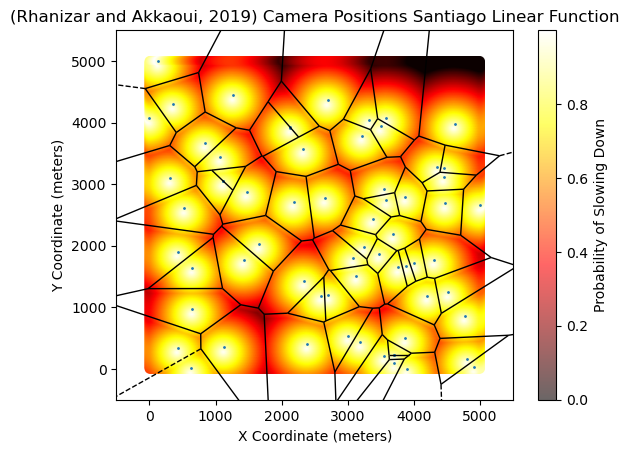

Average Coverage Probability: 0.5612650902607739


In [10]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.stats import ttest_rel

# Record the start time
start_time = time.time()


# Load the crash data
provi_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Rh_Ak/Santiago/RA_Stgo_Coordinates.csv')  # Replace with your file path
provi_df[['Y', 'X']] = provi_df['(X,Y)'].str.split(',', expand=True).astype(float)  # Split the column into two new columns and convert to float
provi_df = provi_df.dropna()
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
probability_threshold = 0.7  # Probability threshold for coverage


# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    # Linear function parameters as solved previously
    a = -1/1000
    b = 1
    probability = a * dist + b
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)
    
# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, '(Rhanizar and Akkaoui, 2019) Camera Positions Santiago Linear Function')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)

# Save to CSV
#comparison_output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Rh_Ak/Data/Rhanizar_Akkaoui_Camera_Positions_Coordinates_Final.csv'  # Adjust the path as necessary
#provi_df.to_csv(comparison_output_csv_path, index=False)

In [ ]:
#Plots: Logarithmic

<Figure size 1200x800 with 0 Axes>

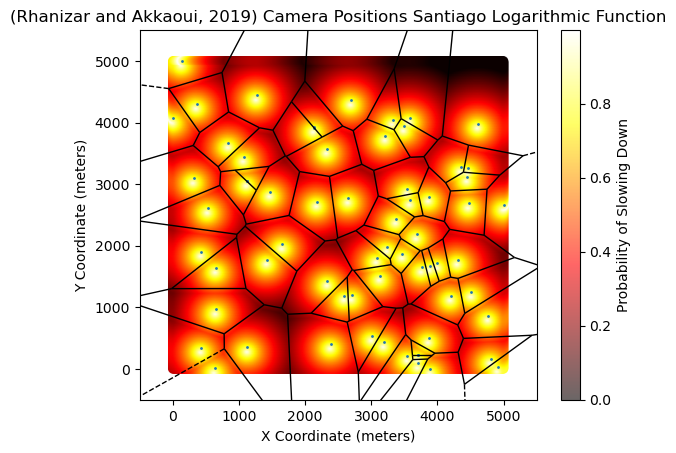

Average Coverage Probability: 0.40167647253412286


In [9]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.stats import ttest_rel

# Record the start time
start_time = time.time()


# Load the crash data
provi_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Rh_Ak/Santiago/RA_Stgo_Coordinates.csv')  # Replace with your file path
provi_df[['Y', 'X']] = provi_df['(X,Y)'].str.split(',', expand=True).astype(float)  # Split the column into two new columns and convert to float
provi_df = provi_df.dropna()
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
probability_threshold = 0.7  # Probability threshold for coverage


# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    k = 0.005
    probability = 1 - np.log(1 + k * dist) / np.log(1 + k * 1000)
    # Ensure the probability is never negative and does not exceed 1, applied to each element of the array
    probability = np.clip(probability, 0, 1)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)
    
# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, '(Rhanizar and Akkaoui, 2019) Camera Positions Santiago Logarithmic Function')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)

# Save to CSV
#comparison_output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Rh_Ak/Data/Rhanizar_Akkaoui_Camera_Positions_Coordinates_Final.csv'  # Adjust the path as necessary
#provi_df.to_csv(comparison_output_csv_path, index=False)

In [ ]:
#Plots: Quadratic

<Figure size 1200x800 with 0 Axes>

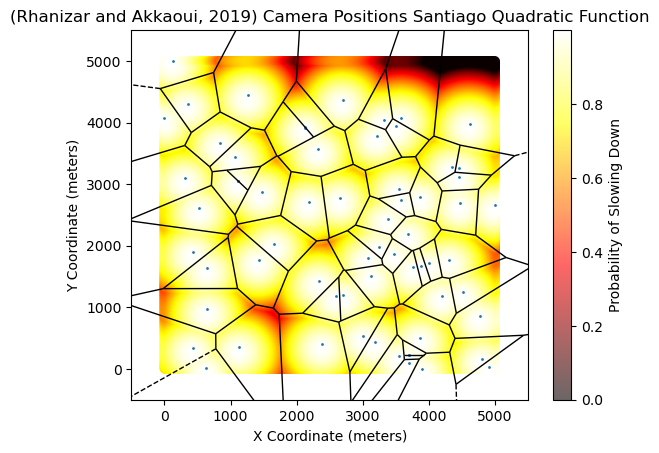

Average Coverage Probability: 0.7314213873847697


In [8]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
from scipy.stats import ttest_rel

# Record the start time
start_time = time.time()


# Load the crash data
provi_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Results_V3/Rh_Ak/Santiago/RA_Stgo_Coordinates.csv')  # Replace with your file path
provi_df[['Y', 'X']] = provi_df['(X,Y)'].str.split(',', expand=True).astype(float)  # Split the column into two new columns and convert to float
provi_df = provi_df.dropna()
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
probability_threshold = 0.7  # Probability threshold for coverage


# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    a = -1/1000**2
    c = 1
    probability = a * dist**2 + c
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    
    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if not region:
            continue
        
        # Get all the vertices of the Voronoi region
        vertices = vor.vertices[region, :]
        # Filter out vertices that are not within the area bounds
        vertices = vertices[(vertices[:, 0] >= 0) & (vertices[:, 0] <= area_size[0]) &
                            (vertices[:, 1] >= 0) & (vertices[:, 1] <= area_size[1])]
        
        # Compute probabilities for the cell points within the region
        if len(vertices) > 0:
            cell_mask = np.all((grid_points >= vertices.min(axis=0)) & 
                               (grid_points <= vertices.max(axis=0)), axis=1)
            cell_points = grid_points[cell_mask]
            if len(cell_points) > 0:
                distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                probabilities = probability_of_slowing(distances.min(axis=1))
                voronoi_coverage.append(np.mean(probabilities))
            else:
                voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))
        else:
            voronoi_coverage.append(calculate_edge_probability(camera_positions[point_index], area_size))

    if return_individual:
        return voronoi_coverage
    else:
        return np.mean(voronoi_coverage)

def calculate_edge_probability(camera_position, area_size):
    max_distance = np.max([np.linalg.norm(camera_position - np.array([0, 0])),
                           np.linalg.norm(camera_position - np.array([area_size[0], 0])),
                           np.linalg.norm(camera_position - np.array([0, area_size[1]])),
                           np.linalg.norm(camera_position - np.array(area_size))])
    return probability_of_slowing(max_distance)
    
# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, '(Rhanizar and Akkaoui, 2019) Camera Positions Santiago Quadratic Function')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Average Coverage Probability: {initial_avg_probability}")
initial_probabilities = calculate_voronoi_coverage(grid_points, camera_positions, return_individual=True)

# Save to CSV
#comparison_output_csv_path = '/Users/sebi/Documents/Datos Tesis MIIIO/Rh_Ak/Data/Rhanizar_Akkaoui_Camera_Positions_Coordinates_Final.csv'  # Adjust the path as necessary
#provi_df.to_csv(comparison_output_csv_path, index=False)